# Partie II – CNN et vision par ordinateur

Classification **Fashion-MNIST** avec CNN LeNet.

- Conv2d, max/avg pooling (manuel + PyTorch)
- Comparaison MLP vs CNN
- Expériences architecturales et cartes de caractéristiques

> Exécuter les cellules dans l'ordre. Les figures s'affichent sous chaque cellule et sont aussi enregistrées dans `figures/`.


In [1]:
#Idem Partie I : configure le répertoire racine.
%matplotlib inline
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "partie1_mlp").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)



## Configuration et imports


In [2]:
#Importe torchvision, fixe device/seed, batch=256, epochs=5, et un sous-échantillon de 10 000/2 000 images pour aller plus vite.
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
FIG_DIR = ROOT / "figures" / "partie2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 256
EPOCHS = 5
ARCH_EPOCHS = 3
LR = 1e-3
SUBSET_TRAIN = 10000
SUBSET_TEST = 2000


## 1. Implémentations manuelles : conv2d, max-pool, avg-pool


In [3]:
#Réimplémente conv2d, max_pool2d, avg_pool2d avec des boucles Python, puis vérifie qu'ils donnent le même résultat que PyTorch.
def manual_conv2d(input_tensor: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor,
                  stride: int = 1, padding: int = 0) -> torch.Tensor:
    """
    Corrélation croisée 2D manuelle (équivalent nn.Conv2d sans groups).
    input: (N, C_in, H, W), weight: (C_out, C_in, kH, kW)
    """
    if padding > 0:
        input_tensor = torch.nn.functional.pad(
            input_tensor, (padding, padding, padding, padding)
        )
    batch, in_c, h, w = input_tensor.shape
    out_c, _, kH, kW = weight.shape
    out_h = (h - kH) // stride + 1
    out_w = (w - kW) // stride + 1
    output = torch.zeros(batch, out_c, out_h, out_w, device=input_tensor.device)

    for b in range(batch):
        for oc in range(out_c):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * stride
                    w_start = j * stride
                    region = input_tensor[b, :, h_start:h_start + kH, w_start:w_start + kW]
                    output[b, oc, i, j] = torch.sum(region * weight[oc]) + bias[oc]
    return output


def manual_max_pool2d(input_tensor: torch.Tensor, kernel_size: int, stride: int = None) -> torch.Tensor:
    stride = stride or kernel_size
    batch, channels, h, w = input_tensor.shape
    out_h = (h - kernel_size) // stride + 1
    out_w = (w - kernel_size) // stride + 1
    output = torch.zeros(batch, channels, out_h, out_w, device=input_tensor.device)

    for b in range(batch):
        for c in range(channels):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * stride
                    w_start = j * stride
                    region = input_tensor[b, c, h_start:h_start + kernel_size, w_start:w_start + kernel_size]
                    output[b, c, i, j] = region.max()
    return output


def manual_avg_pool2d(input_tensor: torch.Tensor, kernel_size: int, stride: int = None) -> torch.Tensor:
    stride = stride or kernel_size
    batch, channels, h, w = input_tensor.shape
    out_h = (h - kernel_size) // stride + 1
    out_w = (w - kernel_size) // stride + 1
    output = torch.zeros(batch, channels, out_h, out_w, device=input_tensor.device)

    for b in range(batch):
        for c in range(channels):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * stride
                    w_start = j * stride
                    region = input_tensor[b, c, h_start:h_start + kernel_size, w_start:w_start + kernel_size]
                    output[b, c, i, j] = region.mean()
    return output


def compare_manual_vs_pytorch():
    """Compare les implémentations manuelles avec PyTorch."""
    x = torch.randn(2, 1, 8, 8)
    conv = nn.Conv2d(1, 3, kernel_size=3, stride=1, padding=1, bias=True)
    conv.eval()

    manual_out = manual_conv2d(x, conv.weight, conv.bias, stride=1, padding=1)
    pytorch_out = conv(x)
    conv_diff = torch.max(torch.abs(manual_out - pytorch_out)).item()

    max_pool = nn.MaxPool2d(2, stride=2)
    manual_max = manual_max_pool2d(x, kernel_size=2, stride=2)
    pytorch_max = max_pool(x)
    max_diff = torch.max(torch.abs(manual_max - pytorch_max)).item()

    avg_pool = nn.AvgPool2d(2, stride=2)
    manual_avg = manual_avg_pool2d(x, kernel_size=2, stride=2)
    pytorch_avg = avg_pool(x)
    avg_diff = torch.max(torch.abs(manual_avg - pytorch_avg)).item()

    print("--- Comparaison manuel vs PyTorch ---")
    print(f"  Conv2d max diff: {conv_diff:.6e}")
    print(f"  MaxPool max diff: {max_diff:.6e}")
    print(f"  AvgPool max diff: {avg_diff:.6e}")

    # Calcul dimensionnel manuel (exemple du sujet)
    print("\n--- Calcul dimensionnel (exemple) ---")
    H, W, k, p, s = 28, 28, 5, 2, 1
    out_h = (H + 2 * p - k) // s + 1
    out_w = (W + 2 * p - k) // s + 1
    print(f"  Conv: input 28x28, k=5, p=2, s=1 -> output {out_h}x{out_w}")
    pool_k, pool_s = 2, 2
    pool_h = out_h // pool_s
    pool_w = out_w // pool_s
    print(f"  Pool: k=2, s=2 -> output {pool_h}x{pool_w}")

    return {"conv_diff": conv_diff, "max_diff": max_diff, "avg_diff": avg_diff}


## 2. Architectures : MLP vs LeNet-style CNN


In [4]:
#Un MLP "à plat" (Flatten+Linear) vs un CNN type LeNet (conv+pool x2 + FC),
#paramétrable (padding, stride, type de pool, nb filtres, conv 1x1) pour les expériences
class ImageMLP(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class LeNetCNN(nn.Module):
    """CNN inspiré de LeNet-5 adapté à Fashion-MNIST (28x28)."""

    def __init__(self, num_classes: int = 10, num_filters: int = 6,
                 padding: int = 0, stride: int = 1, pool_type: str = "max",
                 use_1x1: bool = False):
        super().__init__()
        self.use_1x1 = use_1x1
        self.pool_type = pool_type

        layers = []
        if use_1x1:
            layers.extend([
                nn.Conv2d(1, 16, kernel_size=1),
                nn.ReLU(),
            ])
            in_ch = 16
        else:
            in_ch = 1

        layers.extend([
            nn.Conv2d(in_ch, num_filters, kernel_size=5, stride=stride, padding=padding),
            nn.ReLU(),
        ])
        self.features = nn.Sequential(*layers)

        if pool_type == "max":
            self.pool = nn.MaxPool2d(2, stride=2)
        else:
            self.pool = nn.AvgPool2d(2, stride=2)

        self.conv2 = nn.Conv2d(num_filters, 16, kernel_size=5)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, stride=2)

        # Taille dynamique calculée après conv (pour padding/stride variables)
        self._fc_input_dim = None
        self.fc1 = None
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def _build_fc(self, x):
        with torch.no_grad():
            feat = self._forward_features(x)
            flat = feat.view(x.size(0), -1)
            self._fc_input_dim = flat.shape[1]
            self.fc1 = nn.Linear(self._fc_input_dim, 120).to(x.device)

    def _forward_features(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.relu2(self.conv2(x))
        x = self.pool2(x)
        return x

    def forward(self, x, return_features: bool = False):
        if self.fc1 is None:
            self._build_fc(x)
        feat = self._forward_features(x)
        flat = feat.view(x.size(0), -1)
        x = torch.relu(self.fc1(flat))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        if return_features:
            return logits, feat
        return logits


## 3. Données


In [5]:
#Télécharge Fashion-MNIST, normalise, prend un sous-ensemble aléatoire, crée les DataLoaders train/test.
def get_dataloaders():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),
    ])
    train_full = torchvision.datasets.FashionMNIST(
        root=str(ROOT / "data"), train=True, download=True, transform=transform
    )
    test_set = torchvision.datasets.FashionMNIST(
        root=str(ROOT / "data"), train=False, download=True, transform=transform
    )

    train_indices = torch.randperm(len(train_full))[:SUBSET_TRAIN]
    train_set = Subset(train_full, train_indices)
    test_indices = torch.randperm(len(test_set))[:SUBSET_TEST]
    test_subset = Subset(test_set, test_indices)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_loader, test_loader, train_full.classes


## 4. Entraînement


In [6]:
#train_one_epoch, evaluate_acc, train_model : boucle classique avec sauvegarde du meilleur modèle (sélectionné directement sur le test,
#pas de val séparée ici)
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total


def evaluate_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


def train_model(model, train_loader, test_loader, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_acc = evaluate_acc(model, test_loader)
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())
        if (epoch + 1) % 4 == 0:
            print(f"    Epoch {epoch+1}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    model.load_state_dict(best_state)
    return model, best_acc


## 5. Visualisation des cartes de caractéristiques


In [7]:
#Affiche ce que "voit" le premier filtre convolutif sur quelques images, comparé à l'image originale.
def visualize_feature_maps(model, loader, class_names, save_path):
    model.eval()
    xb, yb = next(iter(loader))
    xb = xb[:8].to(DEVICE)
    with torch.no_grad():
        _, features = model(xb, return_features=True)

    # Première couche conv
    first_conv = model.features[0 if not model.use_1x1 else 2]
    with torch.no_grad():
        if model.use_1x1:
            x_prep = model.features[0](xb)
            x_prep = model.features[1](x_prep)
            conv1_out = first_conv(x_prep)
        else:
            conv1_out = first_conv(xb)

    n_maps = min(6, conv1_out.shape[1])
    fig, axes = plt.subplots(2, n_maps, figsize=(2 * n_maps, 4))
    for i in range(n_maps):
        axes[0, i].imshow(conv1_out[0, i].cpu(), cmap="viridis")
        axes[0, i].set_title(f"Filtre {i}")
        axes[0, i].axis("off")
        axes[1, i].imshow(xb[0, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")
    plt.suptitle(f"Cartes de caractéristiques (classe: {class_names[yb[0]]})")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## 6. Expérimentations architecturales


In [8]:
#Compare 6 variantes du CNN (baseline, padding=2, stride=2, avg_pool, 16 filtres, conv 1x1) et trace un histogramme des accuracies.
def run_architecture_experiments(train_loader, test_loader):
    configs = [
        {"name": "baseline", "padding": 0, "stride": 1, "pool_type": "max", "num_filters": 6, "use_1x1": False},
        {"name": "padding=2", "padding": 2, "stride": 1, "pool_type": "max", "num_filters": 6, "use_1x1": False},
        {"name": "stride=2", "padding": 0, "stride": 2, "pool_type": "max", "num_filters": 6, "use_1x1": False},
        {"name": "avg_pool", "padding": 0, "stride": 1, "pool_type": "avg", "num_filters": 6, "use_1x1": False},
        {"name": "filters=16", "padding": 0, "stride": 1, "pool_type": "max", "num_filters": 16, "use_1x1": False},
        {"name": "conv 1x1", "padding": 0, "stride": 1, "pool_type": "max", "num_filters": 6, "use_1x1": True},
    ]
    results = {}
    for cfg in configs:
        print(f"  Expérience: {cfg['name']}")
        model = LeNetCNN(
            padding=cfg["padding"], stride=cfg["stride"],
            pool_type=cfg["pool_type"], num_filters=cfg["num_filters"],
            use_1x1=cfg["use_1x1"],
        )
        _, acc = train_model(model, train_loader, test_loader, epochs=ARCH_EPOCHS)
        results[cfg["name"]] = acc
        print(f"    -> test accuracy: {acc:.4f}")
    return results


def plot_experiment_results(results, save_path):
    names = list(results.keys())
    accs = list(results.values())
    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, accs, color="steelblue", edgecolor="black")
    plt.ylabel("Accuracy (test)")
    plt.title("Influence des choix architecturaux – CNN LeNet")
    plt.xticks(rotation=30, ha="right")
    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{acc:.3f}", ha="center", fontsize=9)
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## 7. Exécution


## Expériences


### Préparation


In [9]:
#Lance la vérification manuelle vs PyTorch + charge réellement les données.
print(f"Device : {DEVICE}")
compare_manual_vs_pytorch()

train_loader, test_loader, class_names = get_dataloaders()
print(f"Train subset: {len(train_loader.dataset)} | Test: {len(test_loader.dataset)}")


Device : cpu
--- Comparaison manuel vs PyTorch ---
  Conv2d max diff: 2.384186e-07
  MaxPool max diff: 0.000000e+00
  AvgPool max diff: 5.960464e-08

--- Calcul dimensionnel (exemple) ---
  Conv: input 28x28, k=5, p=2, s=1 -> output 28x28
  Pool: k=2, s=2 -> output 14x14
Train subset: 10000 | Test: 2000


### MLP vs CNN



--- Comparaison MLP vs CNN ---


    Epoch 4: train_acc=0.8324, test_acc=0.8245


MLP test accuracy: 0.8245


    Epoch 4: train_acc=0.7079, test_acc=0.7205


CNN test accuracy: 0.7345


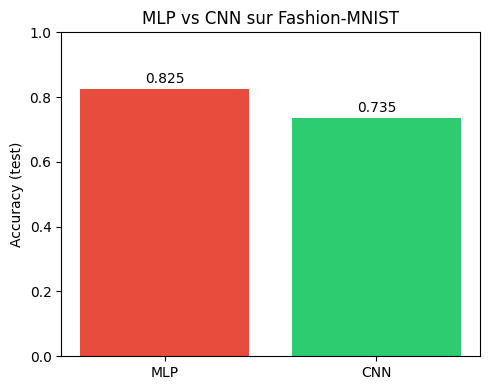

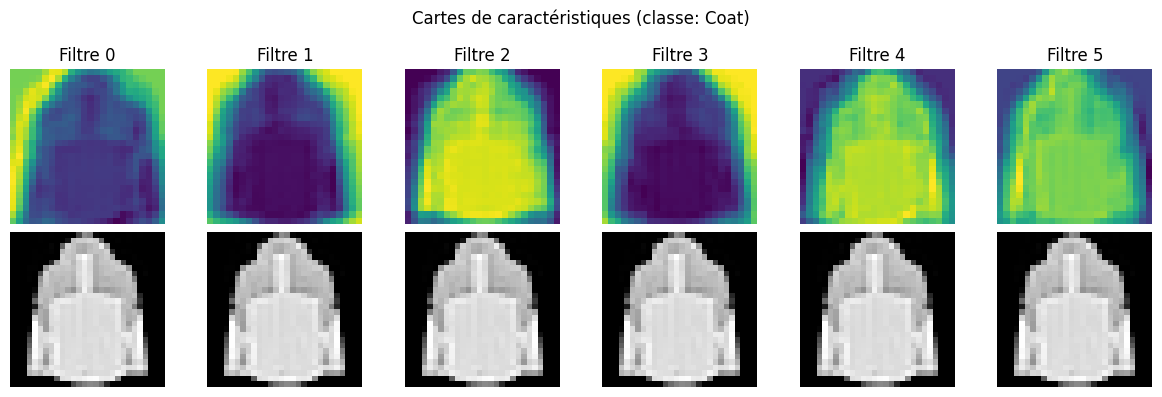


--- Expérimentations architecturales ---
  Expérience: baseline


    -> test accuracy: 0.6730
  Expérience: padding=2


    -> test accuracy: 0.7120
  Expérience: stride=2


    -> test accuracy: 0.7095
  Expérience: avg_pool


    -> test accuracy: 0.7075
  Expérience: filters=16


    -> test accuracy: 0.7180
  Expérience: conv 1x1


    -> test accuracy: 0.6810


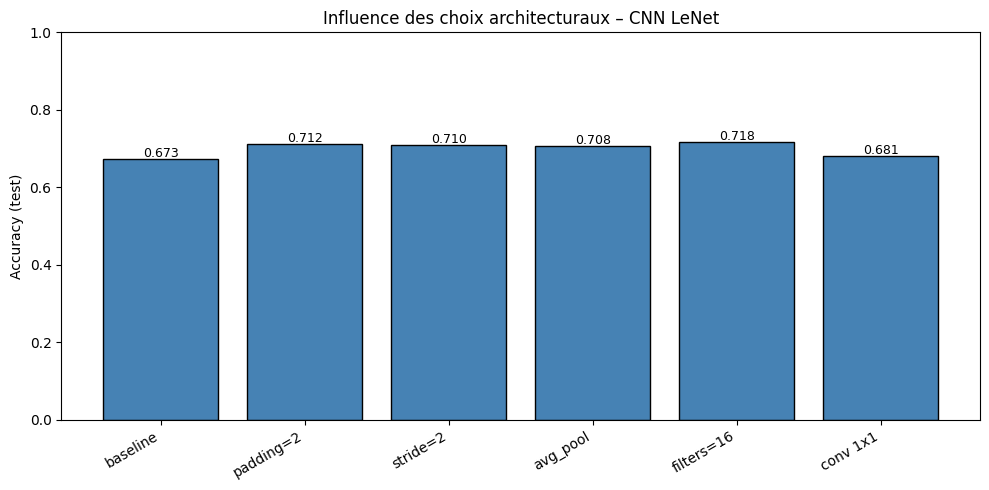


Résultats exportés. Figures dans c:\Users\Legion\deep-learning-projet\figures\partie2


In [10]:
#Entraîne MLP et CNN, compare leurs accuracies, affiche les feature maps, lance les 6 expériences d'architecture, puis exporte tout en JSON.
print("\n--- Comparaison MLP vs CNN ---")
mlp = ImageMLP()
mlp, mlp_acc = train_model(mlp, train_loader, test_loader)
print(f"MLP test accuracy: {mlp_acc:.4f}")

cnn = LeNetCNN()
cnn, cnn_acc = train_model(cnn, train_loader, test_loader)
print(f"CNN test accuracy: {cnn_acc:.4f}")

plt.figure(figsize=(5, 4))
plt.bar(["MLP", "CNN"], [mlp_acc, cnn_acc], color=["#e74c3c", "#2ecc71"])
plt.ylabel("Accuracy (test)")
plt.title("MLP vs CNN sur Fashion-MNIST")
plt.ylim(0, 1.0)
for i, v in enumerate([mlp_acc, cnn_acc]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_vs_cnn.png", dpi=150)
plt.show()

visualize_feature_maps(cnn, test_loader, class_names, FIG_DIR / "feature_maps.png")

print("\n--- Expérimentations architecturales ---")
arch_results = run_architecture_experiments(train_loader, test_loader)
plot_experiment_results(arch_results, FIG_DIR / "arch_experiments.png")

summary = {
    "device": str(DEVICE),
    "mlp_accuracy": mlp_acc,
    "cnn_accuracy": cnn_acc,
    "architecture_experiments": arch_results,
}
with open(ROOT / "partie2_cnn" / "results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nRésultats exportés. Figures dans {FIG_DIR}")
